In [21]:
import sys
import pandas as pd
import numpy as np

sys.path.append('../../evaluation_utils/')
from evaluation import evaluation_func as fp_eval

from collections import OrderedDict

In [22]:
color_dict = OrderedDict()

color_dict["Methods"] = OrderedDict({
    "FedProt":"black",
    "Fisher":"#D44400",
    "Stouffer":"#E69F00",
    "REM":"#2E5EAA",
    "RankProd":"#009E73"
})

# Read results

In [23]:
dfs = {}

workdir = "/home/yuliya/repos/cosybio/FedProt/evaluation/" 
df = fp_eval.read_results(
    workdir,
    deqms_name="bacterial_data_protocols/results/central_res_NONU.tsv",
    fedprot_name="bacterial_data_protocols/results/DPE.csv",
    fisher_name="bacterial_data_protocols/results/MA_CM.tsv",
    rem_name="bacterial_data_protocols/results/MA_REM.tsv",
    stouffer_name="bacterial_data_protocols/results/MA_Stouffer.tsv",   
    rankprod_name="bacterial_data_protocols/results/MA_RankProd.tsv"
)
dfs["Bacterial dataset, NON-uniform preprocessing"] = df
print(f"Proteins: {len(df)}")


Results loaded for DEqMS with 2928 proteins.
Results loaded for FedProt with 2928 proteins.
Results loaded for Fisher with 2870 proteins.
Results loaded for REM with 3097 proteins.


Results loaded for Stouffer with 2304 proteins.
Results loaded for RankProd with 3097 proteins.
Results loaded from /home/yuliya/repos/cosybio/FedProt/evaluation/ with 2304 genes. Adj.p-values were not log-transformed.


Proteins: 2304


In [24]:
log_dfs = {}
for k in dfs:
    df = dfs[k]
    df = df.replace(0,1e-300)
    # df["pv_DEqMS"] = -np.log10(df["pv_DEqMS"])
    for m in ["DEqMS", "FedProt", "Fisher","Stouffer","REM","RankProd"]:
        df.loc[df["pv_"+m] < 1e-300, "pv_"+m] = 1e-300
        df.loc[:, "pv_"+m] = -np.log10(df["pv_"+m])
    log_dfs[k] = df

# Stats calculation

In [25]:
root_dir = "/home/yuliya/repos/cosybio/FedProt/evaluation/bacterial_data_protocols/"

for dataset in log_dfs:

    pval_basic_stats = fp_eval.calc_stats(
        log_dfs[dataset], 
        lfc_thr=0.58, adj_pval_thr=0.01,
        stats=["MeanDiff", "MaxDiff"],
        methods=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"],
        column_name="pv_",
        top_genes=-1
    )
    logfc_basic_stats = fp_eval.calc_stats(
        log_dfs[dataset],
        lfc_thr=0.58, adj_pval_thr=0.01,
        stats=["MeanDiff", "MaxDiff"],
        methods=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"],
        column_name="lfc_",
        top_genes=-1
    )

    pval_basic_stats.to_csv(f'{root_dir}/tables/{dataset}_pval_basic_stats_NONUF.csv')
    logfc_basic_stats.to_csv(f'{root_dir}/tables/{dataset}_logfc_basic_stats_NONUF.csv')

    print(f'Dataset: {dataset}')
    print("\tLogFC basic stats:")
    print(logfc_basic_stats)
    print("\tP-value basic stats:")
    print(pval_basic_stats)        

Dataset: Bacterial dataset, NON-uniform preprocessing
	LogFC basic stats:
              MeanDiff       MaxDiff
FedProt   1.008863e-14  4.285461e-14
Fisher    3.696856e-03  2.721563e-01
Stouffer  3.696856e-03  2.721563e-01
REM       1.970395e-02  4.142551e-01
RankProd  3.696856e-03  2.721563e-01
	P-value basic stats:
              MeanDiff       MaxDiff
FedProt   3.836929e-13  3.042899e-12
Fisher    3.375354e+00  2.800275e+01
Stouffer  3.007697e+00  2.780135e+01
REM       1.662746e+01  2.522132e+02
RankProd  1.378623e+01  8.735031e+01


In [26]:
# shorter version of log_dfs taking only 50% of rows randomly
short_log_dfs = {}
for dataset in log_dfs:
    short_log_dfs[dataset] = log_dfs[dataset].sample(frac=0.25, random_state=1)
    print(f"Dataset: {dataset}, proteins: {len(short_log_dfs[dataset])}")

Dataset: Bacterial dataset, NON-uniform preprocessing, proteins: 576


Plotting correlation using p-vals - log-transformed.


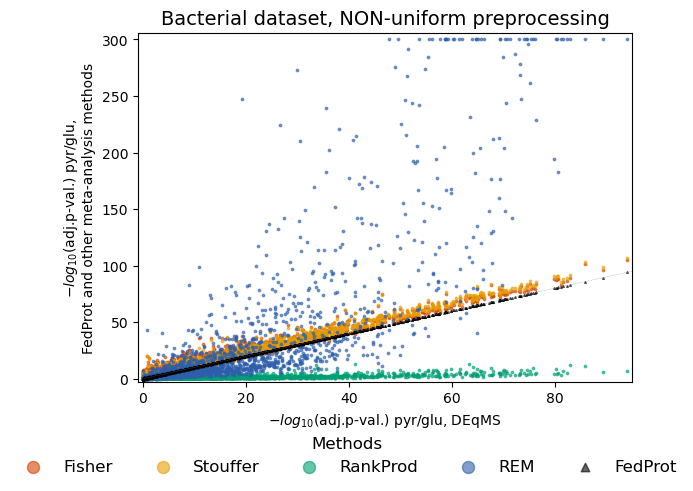

In [27]:
plot_one = fp_eval.plt_results(
    log_dfs, 
    methods=["Fisher", "Stouffer", "RankProd", "REM", "FedProt"],
    color_dict=color_dict,
    what="pv_", 
    text="", dotsize=3,
    datasets=list(log_dfs.keys()),
    figsize=(6,4.5),
    add_table=False,
    sharex=False, sharey=False,
    comparsions=["pyr/glu", "control/FSGS"],
    bbox_to_anchor_param=(0.5, -0.1)
)

# plt.savefig("/home/yuliya/repos/cosybio/FedDEqMS/data/04_evaluation/plots/" + "Fig3B_prototype.png", dpi=1200)

Plotting correlation using logFC values.


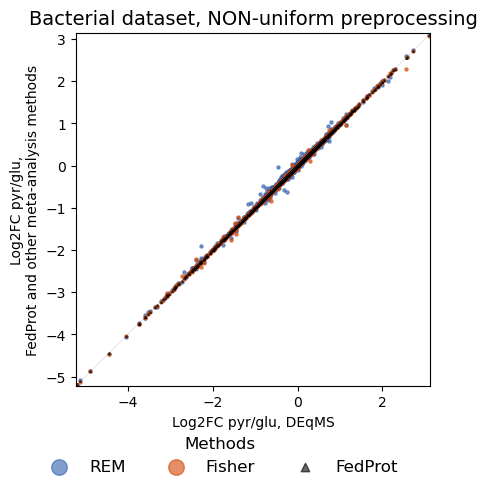

In [28]:
_ = fp_eval.plt_results(
    log_dfs, 
    methods=["REM", "Fisher", "FedProt"],
    color_dict=color_dict,
    what="lfc_", 
    text="", dotsize=5,
    figsize=(4.5,4.5),
    datasets=list(log_dfs.keys()),
    add_table=False,
    sharex =False, sharey=False,
    comparsions=["pyr/glu", "control/FSGS"],
    # set_lims = [[-2,2], [-0.8, 0.8]],
    bbox_to_anchor_param=(0.5, -0.1)
)

# plt.savefig("/home/yuliya/repos/cosybio/FedDEqMS/data/04_evaluation/plots/" + "Fig3B_prototype.png", dpi=1200)

# Top lists

In [29]:
fp_fn_b = fp_eval.calc_stats(
    log_dfs["Bacterial dataset, NON-uniform preprocessing"], 
    lfc_thr=0.5, adj_pval_thr=0.05,
    stats=["FP", "FN", "Jaccard"],
    methods=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"],
    column_name="pv_",
    top_genes=-1
)
fp_fn_b.to_csv(f'{root_dir}/tables/Bacterial_FP_FN_NONUF.csv')
# for Jaccard column, round to 3 decimal places
fp_fn_b["Jaccard"] = fp_fn_b["Jaccard"].round(3)

print("\tFP/FN bacterial dataset:")
print(fp_fn_b)  

	FP/FN bacterial dataset:
            FP     FN  Jaccard
FedProt    0.0    0.0    1.000
Fisher     3.0    2.0    0.993
Stouffer   3.0    2.0    0.993
REM       14.0   16.0    0.959
RankProd   0.0  186.0    0.740


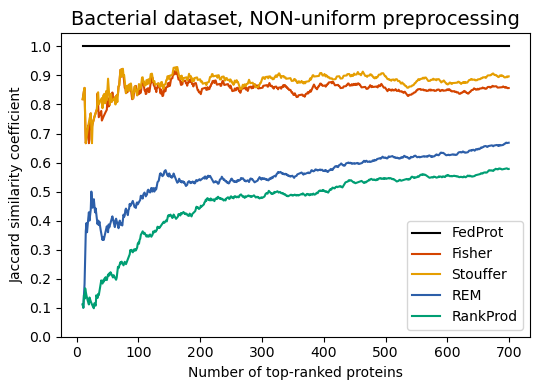

In [31]:
min_n_genes = 10
step = 1

_, _ = fp_eval.plot_stats_for_topN(
    log_dfs,
    datasets = list(log_dfs.keys()),
    methods=["FedProt", "Fisher","Stouffer","REM", "RankProd"],
    metrics=["Jaccard"],
    min_n_genes=min_n_genes,
    max_n_genes=[700, 300],
    figsize=(5.5,4),
    step=step,
    color_dict=color_dict,
    sharey=False,
    )